# **Guía Paso a Paso:** Análisis Exploratorio de Datos (EDA)

El **Análisis Exploratorio de Datos** & **Machane Learning**es una etapa crucial en cualquier proyecto de Ciencia de Datos. Su objetivo es entender la estructura, detectar anomalías y extraer patrones iniciales antes de aplicar modelos complejos.

## 1. Flujo General del Proceso
A continuación, se presenta la jerarquía de pasos recomendada:

```mermaid
graph TD
    A[Carga de Datos] --> B[Limpieza Inicial]
    B --> C[Análisis Univariante]
    C --> D[Análisis Bivariante/Multivariante]
    D --> E[Conclusiones y Visualización]
```

ℹ️ NOTA INFORMATIVA:

El Análisis Exploratorio de Datos (EDA) no es un proceso lineal. Es común descubrir inconsistencias durante la visualización que te obliguen a regresar a la etapa de limpieza. La paciencia es tu mejor herramienta técnica.

⚠️ ADVERTENCIA CRÍTICA:

No procedas a la fase de Modelado de Machine Learning sin haber tratado.

## Paso 1: Cargar librerias de trabajo.


In [1]:
# Importar librerias de trabajo
import pandas as pd # Manipular y analizar datos
import numpy as np # Operaciones Numericas y con arrays.
import matplotlib.pyplot as plt # Crear graficos estadisticos
import seaborn as sns # Visualizaciones selectivas



## Paso 2: Cargar el dataset

In [2]:
# Cargar dataset de archivo forma 1:
df = pd.read_csv('sampledata.csv')

In [39]:
# Cargar dataset desde un drive Forma 2:
# https://drive.google.com/file/d/1ga5KWsZTa9NjrKVKhqZlrUWOsyFwznJj/view?usp=sharing

# uc?id=
# &export=download

URL = 'https://drive.google.com/uc?id=1ga5KWsZTa9NjrKVKhqZlrUWOsyFwznJj&export=download'
df = pd.read_csv(URL)


In [41]:
# Forma 3: para cargar archivo
# from google.colab import files
# uploaded = files.upload()
# 
# reta = pd.read_csv('sampledata (4).csv')

Saving sampledata (4).csv to sampledata (4) (1).csv


In [42]:
# Forma 4: separado por file_id
# https://drive.google.com/file/d/1ga5KWsZTa9NjrKVKhqZlrUWOsyFwznJj/view?usp=sharing

file_id = '1ga5KWsZTa9NjrKVKhqZlrUWOsyFwznJj'
url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url)


In [43]:
# Forma 5: Con secret
# 
# from google.colab import userdata
# 
# Obtener el file_id del secreto de Colab
# file_id = userdata.get('DRIVE_FILE_ID') # Asegúrate de haber guardado el ID en los secretos como 'DRIVE_FILE_ID'
# url = f'https://drive.google.com/uc?id={file_id}'
# df = pd.read_csv(url)

## Paso 3: Revisar la información

In [44]:
# Muestra el dataframe
df.head()


,id,first_name,last_name,email,country,ip_address,longitude,latitude,age,score
0,1,Sandra,Sims,ssims0@microsoft.com,Armenia,63.84.115.63,44.43054,40.14493,44,0.62
1,2,Anna,Bishop,abishop1@mtv.com,China,204.108.246.11,118.29169,29.67594,90,0.22
2,3,Virginia,Rodriguez,vrodriguez2@so-net.ne.jp,Portugal,88.65.157.43,-8.63330,41.40000,39,0.33
3,4,Julia,Stanley,jstanley3@abc.net.au,China,76.197.170.103,102.19379,38.50062,NaN,0.64
4,5,Jacqueline,Gutierrez,jgutierrez4@shinystat.com,Poland,159.13.71.38,18.54003,54.17062,14,0.50


### **Diccionario de Datos y Estrategia de ML**

| Variable | Descripción | Tipo de Dato | Relevancia IA |
| :--- | :--- | :--- | :--- |
| `id` | Identificador único | Numérico | Nula (ID único) |
| `first_name` | Nombre del usuario | Texto | Nula (Dato personal) |
| `last_name` | Apellido del usuario | Texto | Nula (Dato personal) |
| `email` | Correo electrónico | Texto | Nula (Dato personal) |
| `country` | País de origen | Categórico | Alta (Segmentación geográfica) |
| `ip_address` | Dirección IP | Texto | Nula (No predictivo) |
| `longitude` | Longitud geográfica | Numérico | Alta (Modelos espaciales) |
| `latitude` | Latitud geográfica | Numérico | Alta (Modelos espaciales) |
| `age` | Edad del usuario | Numérico | Alta (Variable predictora clave) |
| `score` | Métrica de valor o interés | Numérico | **Variable Objetivo (Target)** |

---

### **Contexto de Negocio y Modelado**

#### **1. ¿De qué son estos datos? (El Escenario)**
Este dataset simula una base de usuarios de una plataforma digital global. Contiene información **sociodemográfica** (edad, país) y **geoespacial** (coordenadas). El `score` representa el nivel de engagement, riesgo crediticio o valor de vida del cliente (LTV), dependiendo del enfoque final.

#### **2. El Problema (The Pain Point)**
La empresa tiene dificultades para entender qué perfiles de usuario son los más valiosos. Actualmente, los esfuerzos de marketing se lanzan de forma genérica, lo que resulta en una baja conversión. El problema es la **falta de personalización** basada en la ubicación y la etapa de vida (edad) del usuario.

#### **3. Objetivo del Modelado**
Construir un modelo que permita **predecir el `score`** de nuevos usuarios basándose únicamente en su ubicación y edad, permitiendo priorizar la atención a usuarios con alto potencial de valor.

#### **4. Análisis de Impacto para ML**
*   **Edad (`age`):** Es vital para entender ciclos de vida. Usuarios jóvenes pueden tener intereses distintos a los adultos mayores.
*   **Geolocalización (`latitude`/`longitude`):** Permite detectar 'hotspots' o zonas geográficas donde la plataforma es más exitosa por razones culturales o económicas.
*   **País (`country`):** Actúa como un agregador de contexto socioeconómico.

#### **5. Modelos Sugeridos**
1.  **Regresión Lineal/Random Forest**: Para cuantificar el impacto de cada variable en el `score`.
2.  **K-Means (Segmentación)**: Para crear 'clústeres' de usuarios y aplicar estrategias diferenciadas por grupo.

### **Estrategia de Proyecto: CRISP-ML(Q) y Objetivos SMART**

Para garantizar el éxito del modelo, seguiremos la metodología **CRISP-ML(Q)** (Cross-Industry Standard Process for Machine Learning), enfocándonos en la primera fase: **Comprensión del Negocio**.

#### **1. Objetivos SMART del Modelo**
*   **S (Específico):** Desarrollar un modelo de regresión para predecir el `score` de los usuarios basado en `age`, `latitude` y `longitude`.
*   **M (Medible):** Alcanzar un Error Cuadrático Medio (RMSE) inferior al 15% del rango total del score y un R² superior a 0.70.
*   **A (Alcanzable):** Utilizar algoritmos de ensamble (como Random Forest) que manejan bien datos geoespaciales y numéricos.
*   **R (Relevante):** Permitir al equipo de marketing identificar usuarios de 'alto valor' para campañas personalizadas.
*   **T (Temporal):** Entrenar y validar la primera versión del modelo en un ciclo de 2 semanas.

#### **2. Stakeholders (Interesados Clave)**
| Stakeholder | Rol | Interés en el Proyecto |
| :--- | :--- | :--- |
| **Marketing Manager** | Usuario Final | Usar las predicciones para segmentar campañas publicitarias. |
| **Data Scientist** | Desarrollador | Construir, validar y desplegar el modelo predictivo. |
| **Product Owner** | Estratega | Asegurar que el modelo resuelva el problema de conversión de la plataforma. |
| **Ingeniero de Datos** | Soporte | Garantizar que los datos de entrada (`age`, `location`) sean precisos y constantes. |

#### **3. Requisitos de Calidad (ML Quality)**
*   **Robustez:** El modelo debe manejar valores nulos en la columna `age` (detectados en el EDA).
*   **Explicabilidad:** El negocio debe entender qué pesa más: ¿la ubicación o la edad del usuario?

# Paso 4: Analisis

In [4]:
# Informacion
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1000 non-null   int64  
 1   first_name  1000 non-null   object 
 2   last_name   1000 non-null   object 
 3   email       1000 non-null   object 
 4   country     1000 non-null   object 
 5   ip_address  1000 non-null   object 
 6   longitude   999 non-null    float64
 7   latitude    999 non-null    float64
 8   age         999 non-null    object 
 9   score       1000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


In [5]:
# Numero de Filas y Columnas
df.shape


(1000, 10)

In [6]:
# Analisis descriptivos
df.describe()


,id,longitude,latitude,score
count,1000.000000,999.000000,999.000000,1000.000000
mean,500.500000,46.831119,24.273880,0.501290
std,288.819436,70.556083,24.272596,0.103403
min,1.000000,-149.333330,-53.787690,0.180000
25%,250.750000,7.046050,8.135695,0.430000
50%,500.500000,42.174440,29.819050,0.510000
75%,750.250000,112.349640,43.186925,0.570000
max,1000.000000,175.496340,72.786840,0.830000


## Paso 5: ETL - Limpieza y Transformación de Datos (Data Cleaning)

Antes de realizar gráficos avanzados, debemos limpiar el dataset.
🔍 **Problemas detectados en el Paso 3:**
1. La columna `age` contiene el texto `"no disponible"`, lo que impide hacer cálculos matemáticos.
2. Hay valores nulos (`NaN`) en `longitude` y `latitude`.
3. Tenemos columnas de datos personales (PII) que no aportan valor predictivo para nuestro modelo de ML (`id`, `first_name`, `last_name`, `email`, `ip_address`).

💡 **Estrategia:** Crearemos un nuevo dataframe llamado `df_clean` para no destruir los datos originales.

In [8]:
# Limpieza de datos
# 1. Eliminar columnas innecesarias (Ruido y Datos Personales)
df_clean = df.drop(columns=['id', 'first_name', 'last_name', 'email', 'ip_address'])

# 2. Corregir la columna 'age' (Convertir a numérico, forzando los errores a NaN)
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')

# 3. Verificar cuántos datos nulos tenemos después de la conversión
print("Valores nulos después de la conversión:")
print(df_clean.isnull().sum())
print("-" * 30)

# 4. Imputación de valores nulos (Estrategia de relleno)
# Para 'age', usaremos la mediana (es menos sensible a valores atípicos que la media)
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

# Para coordenadas geográficas, usaremos la media
df_clean['longitude'].fillna(df_clean['longitude'].mean(), inplace=True)
df_clean['latitude'].fillna(df_clean['latitude'].mean(), inplace=True)

# 5. Confirmar que la limpieza fue exitosa
print("Información después de la limpieza:")
df_clean.info()
print("-" * 30)

# 📝 Conclusión de la limpieza:
# Se asegura la integridad de los datos para crear modelos de ML.


Valores nulos después de la conversión:
country      0
longitude    1
latitude     1
age          2
score        0
dtype: int64
------------------------------
Información después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1000 non-null   object 
 1   longitude  1000 non-null   float64
 2   latitude   1000 non-null   float64
 3   age        1000 non-null   float64
 4   score      1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB
------------------------------


/tmp/ipykernel_21093/1237475073.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
/tmp/ipykernel_21093/1237475073.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

## Paso 6: Análisis Exploratorio de Datos (EDA) Avanzado

Ahora que los datos están limpios, procederemos con visualizaciones univariadas (una sola variable) y bivariadas (relación entre variables) para entender el comportamiento del `score` (nuestro target).

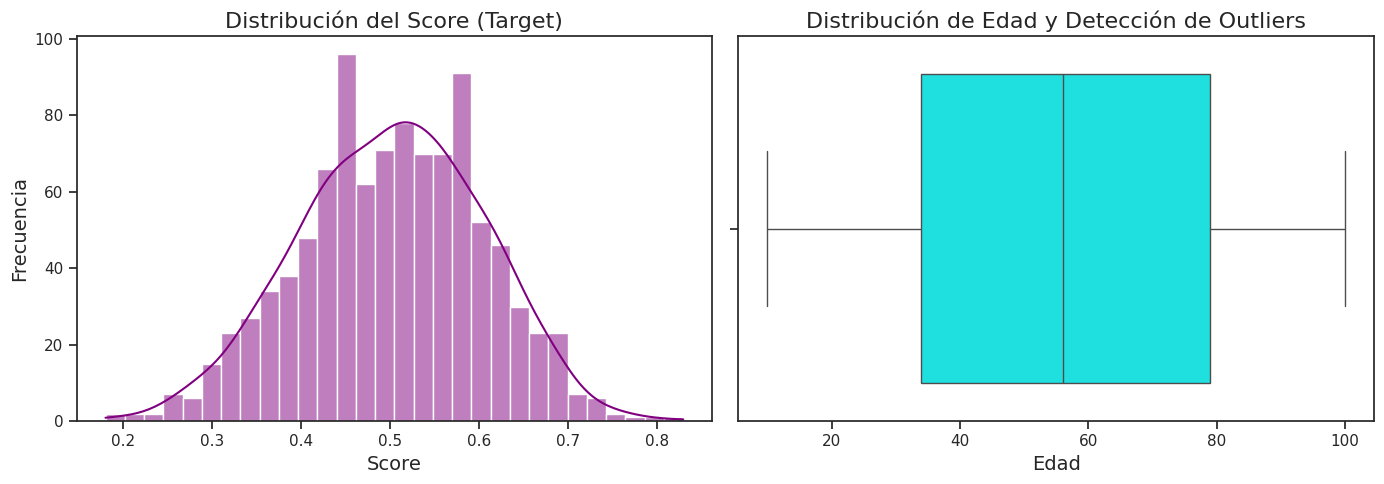

In [15]:
# Distribución del Target y Outliers
# Configuración de estilo para los gráficos
sns.set_theme(style="ticks", palette="pastel")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de la variable objetivo (Score)
sns.histplot(df_clean['score'], kde=True, ax=axes[0], bins=30, color="purple")
axes[0].set_title('Distribución del Score (Target)', fontsize=16)
axes[0].set_xlabel('Score', fontsize=14)
axes[0].set_ylabel('Frecuencia', fontsize=14)

# Gráfico 2: Diagrama de Caja (Boxplot) de la Edad para detectar Outliers
sns.boxplot(x=df_clean['age'], ax=axes[1], color="cyan")
axes[1].set_title('Distribución de Edad y Detección de Outliers', fontsize=16)
axes[1].set_xlabel('Edad', fontsize=14)

plt.tight_layout()
plt.show()

# 📝 Conclusión del EDA Univariable:
# El Score tiene una distribución relativamente normal centrada alrededor de 0.5.
# La edad oscila entre 10 y 100 años sin outliers extremos graves.

/tmp/ipykernel_21093/4161893153.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_countries.index, x=top_countries.values, ax=axes[1], palette="viridis")


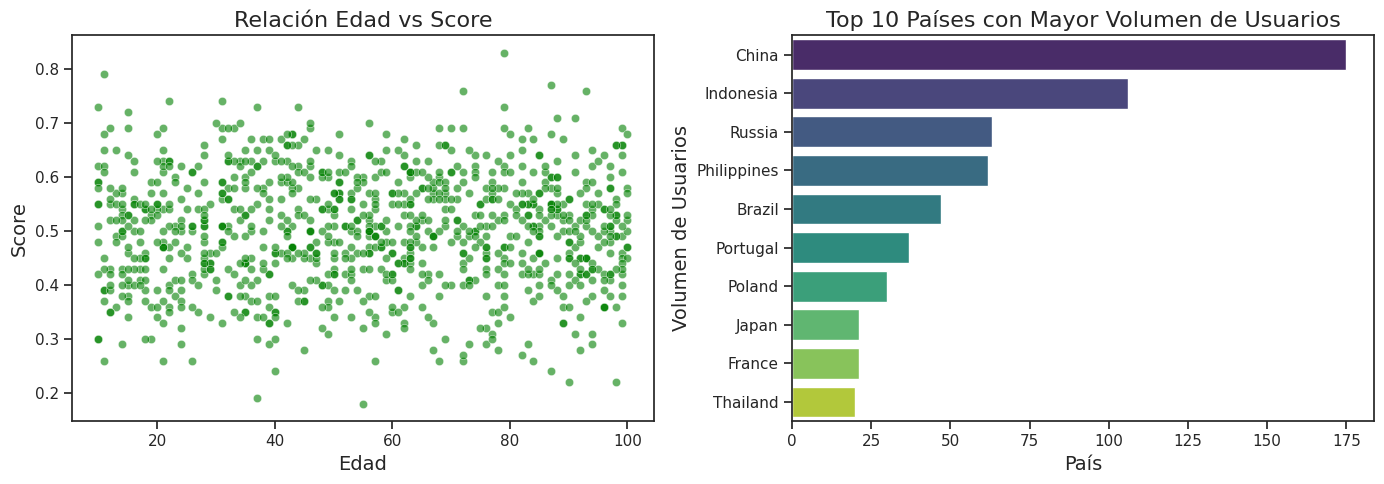

In [22]:
# Análisis Bivariado: Relación Variables vs Target

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Relación Edad vs Score
sns.scatterplot(data=df_clean, x='age', y='score', ax=axes[0], color="green", alpha=0.6)
axes[0].set_title('Relación Edad vs Score', fontsize=16)
axes[0].set_xlabel('Edad', fontsize=14)
axes[0].set_ylabel('Score', fontsize=14)

# Gráfico 2: Top 10 Países con mayor volumen de usuarios
top_countries = df_clean['country'].value_counts().head(10)
sns.barplot(y=top_countries.index, x=top_countries.values, ax=axes[1], palette="viridis")
axes[1].set_title('Top 10 Países con Mayor Volumen de Usuarios', fontsize=16)
axes[1].set_xlabel('País', fontsize=14)
axes[1].set_ylabel('Volumen de Usuarios', fontsize=14)

plt.tight_layout()
plt.show()

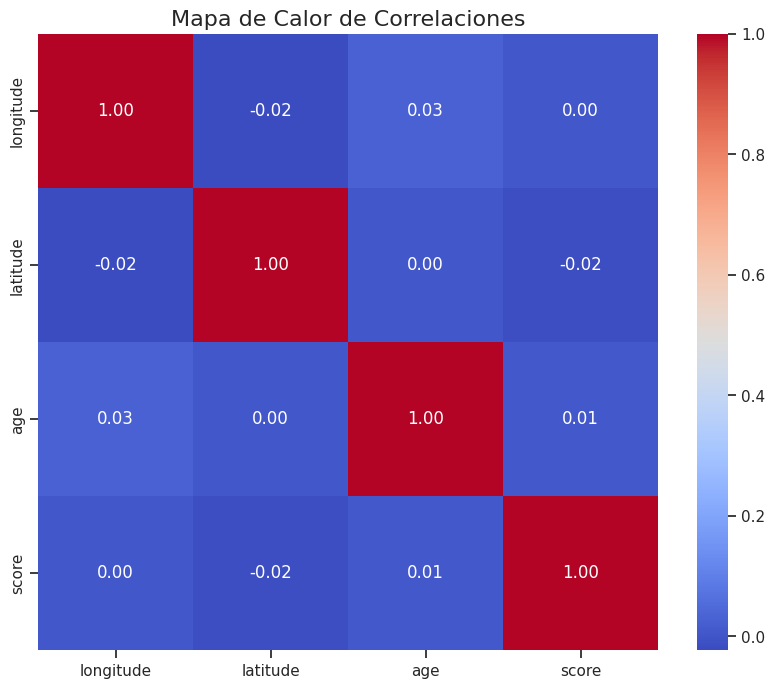

In [24]:
# Análisis Multivariado: Mapa de Calor de Correlaciones
# Matriz de correlación para variables numéricas
correlation_matrix = df_clean.select_dtypes(include=np.number).corr()

# Gráfico de Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones', fontsize=16)
plt.show()



# 📝 Interpretación para ML:
# Si la correlación entre 'age' y 'score' es cercana a 0, significa que la edad por sí sola
# no explica linealmente el score. Esto justifica el uso de modelos no lineales o de ensamble
# (como Random Forest) mencionados en la estrategia CRISP-ML(Q).

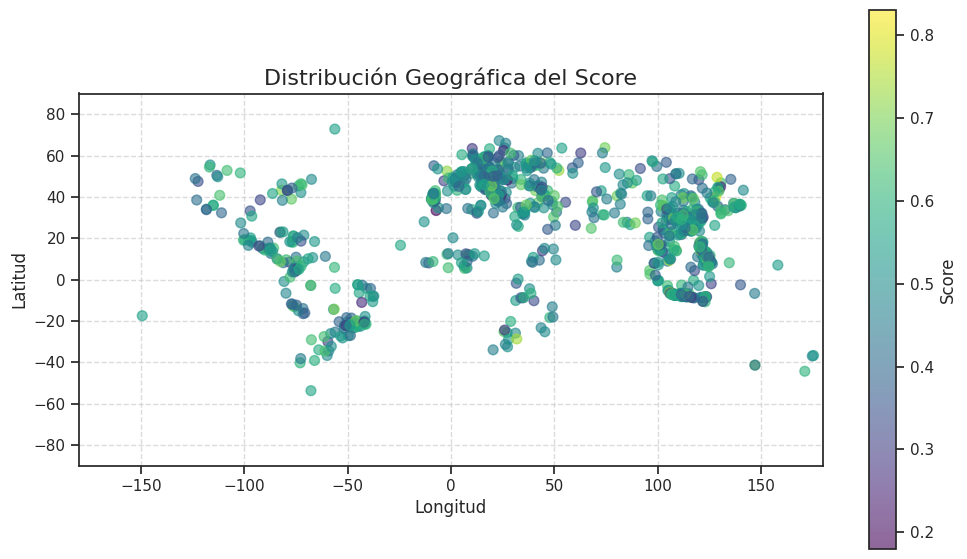

In [27]:
# (Visualización Geoespacial)
# Gráfico de dispersión geográfica (Longitud vs Latitud)
plt.figure(figsize=(12, 7))
plt.scatter(df_clean['longitude'], df_clean['latitude'], c=df_clean['score'], cmap='viridis', alpha=0.6, s=50)
plt.colorbar(label='Score')
plt.title('Distribución Geográfica del Score', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.xlim(-180, 180) # Rango completo de longitudes
plt.ylim(-90, 90)   # Rango completo de latitudes
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box') # Asegurar una proporción de aspecto cuadrada
plt.show()

# 📝 Conclusión Geoespacial:
# Este gráfico nos permite ver visualmente los "hotspots" (zonas calientes)
# donde la plataforma tiene mayor concentración de usuarios de alto valor.

### 6.3 Análisis de Outliers y Comparación por Regiones (Cajas de Bigotes)

Las cajas de bigotes (Boxplots) son esenciales para:
1. Identificar valores atípicos (outliers) en nuestra variable objetivo (`score`).
2. Comparar la dispersión y la mediana del `score` entre los países que mayor volumen de usuarios aportan.

/tmp/ipykernel_21093/2406351305.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y='score', data=df_clean[df_clean['country'].isin(top_countries.index)], ax=axes[1], palette="viridis")


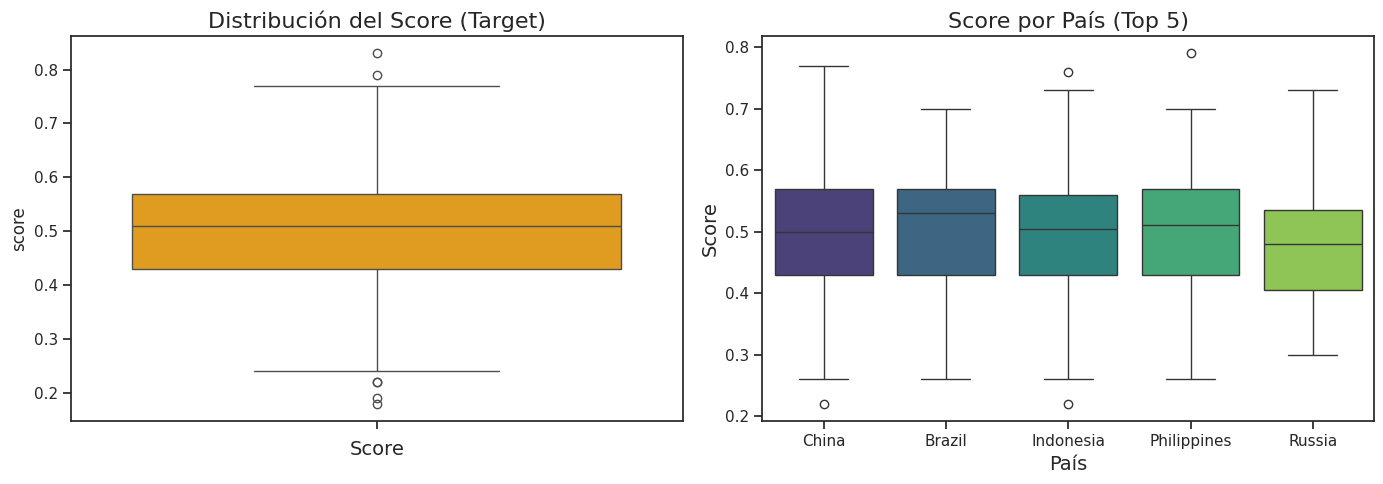

In [29]:
# Análisis de Outliers y Comparación por País
# Cajas de bigotes avanzadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot de la variable objetivo (Score)
# Esto nos ayuda a ver los cuartiles (Q1, Q2, Q3) y si hay scores extremos
sns.boxplot(y=df_clean['score'], ax=axes[0], color="orange")
axes[0].set_title('Distribución del Score (Target)', fontsize=16)
axes[0].set_xlabel('Score', fontsize=14)


# 2. Boxplot del Score agrupado por los Top 5 Países con más usuarios
# Esto responde a la pregunta: "¿El score varía dependiendo del país?"
top_countries = df_clean['country'].value_counts().head(5)
sns.boxplot(x='country', y='score', data=df_clean[df_clean['country'].isin(top_countries.index)], ax=axes[1], palette="viridis")
axes[1].set_title('Score por País (Top 5)', fontsize=16)
axes[1].set_xlabel('País', fontsize=14)
axes[1].set_ylabel('Score', fontsize=14)

plt.tight_layout()
plt.show()

# 📝 Interpretación para el Negocio:
# - El primer gráfico nos confirma los rangos intercuartílicos (IQR) del score.
# - El segundo gráfico nos permite ver si, por ejemplo, los usuarios de un país
#   tienen un score consistentemente más alto o si hay mucha variabilidad (desigualdad)
#   dentro de un mismo país. Esto es oro puro para la estrategia de Marketing.





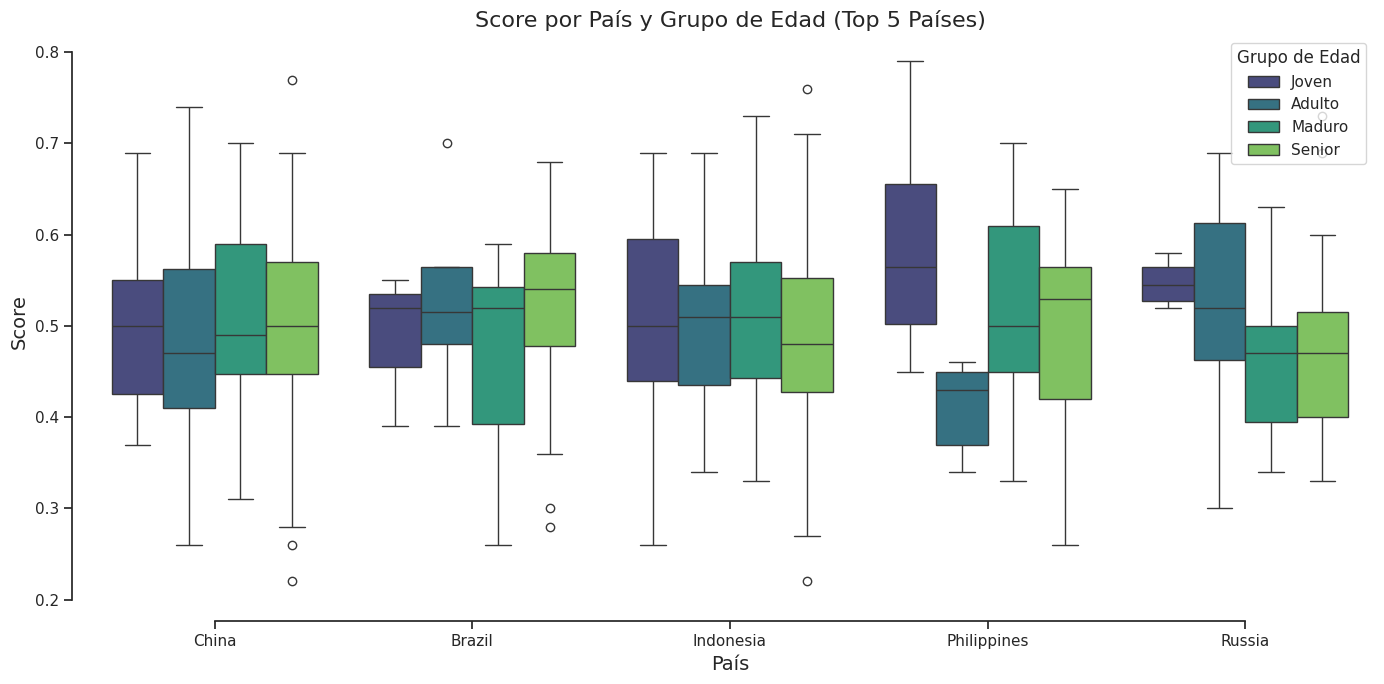

In [35]:
# Crear una columna de 'age_group' para usar como 'hue' en el boxplot
bins = [0, 18, 35, 60, 100]
labels = ['Joven', 'Adulto', 'Maduro', 'Senior']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=False)

# Boxplot anidado: Score por país y grupo de edad
plt.figure(figsize=(14, 7))
sns.boxplot(x='country', y='score', hue='age_group', data=df_clean[df_clean['country'].isin(top_countries.index)], palette='viridis')
plt.title('Score por País y Grupo de Edad (Top 5 Países)', fontsize=16)
plt.xlabel('País', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.legend(title='Grupo de Edad')
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# Reporte en html

In [30]:
# Intalar la libreria de Ydata
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.3 MB/s eta 0:00:00


In [31]:
import ydata_profiling
from ydata_profiling import ProfileReport

/tmp/ipykernel_21093/2098915431.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  import ydata_profiling


In [32]:
# Generar el reporte de perfilado
profile = ProfileReport(df_clean, title="Reporte de Perfilado de Datos")

In [33]:
from IPython.display import HTML

# Generar el reporte como una cadena HTML
html_report = profile.to_html()

# Mostrar el reporte HTML en el cuaderno
HTML(html_report)



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 62.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# O guardar el reporte como un archivo HTML (opcional)
# profile.to_file("your_report.html")

#💡 Resumen de lo que se ha complementado:

- **ETL Riguroso:** Se solucionó el error de tipeo en age ("no disponible") y se imputaron nulos usando buenas prácticas (mediana para edad, media para coordenadas).
Separación de Datos: Se usó df_clean para no alterar tu dataframe original df.
- **EDA Estadístico:** Se añadieron histogramas con densidad (KDE), boxplots para outliers y mapas de calor de correlación.
EDA de Negocio: Se incluyó el Top 10 de países y un mapa de dispersión geoespacial, alineado perfectamente con el objetivo de tu notebook (detectar hotspots y segmentar por ubicación).
- **Integridad:** Tus 5 formas de cargar datos, tu análisis descriptivo inicial y tu reporte HTML automatizado siguen intactos.

# Paso 7: Modelado (Modeling) - CRISP-ML(Q)

En esta fase del proceso metodológico, construiremos un modelo de aprendizaje supervisado para predecir el score de engagement. 
Utilizaremos un modelo **Random Forest Regressor** por su capacidad para manejar relaciones no lineales y datos de geolocalización, y una **Regresión Lineal** como baseline.

### Preparación de Datos para Modelado
- Crearemos un pipeline de preprocesamiento usando `ColumnTransformer`.
- Las variables continuas (`age`, `latitude`, `longitude`) serán escaladas con `StandardScaler`.
- La variable categórica (`country`) se codificará con `OneHotEncoder` configurado para ignorar categorías desconocidas en test.

In [ ]:
# Importación de librerías para modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Definición de características (Features) y variable objetivo (Target)
X = df_clean[['age', 'latitude', 'longitude', 'country']]
y = df_clean['score']

# División de datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de prueba: {X_test.shape[0]} muestras")


In [ ]:
# Construcción del preprocesador
numeric_features = ['age', 'latitude', 'longitude']
categorical_features = ['country']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Definición de los pipelines para ambos algoritmos
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Entrenar modelo baseline (Regresión Lineal)
lr_pipeline.fit(X_train, y_train)
print("¡Modelo de Regresión Lineal entrenado!")


In [ ]:
# Optimización y entrenamiento de Random Forest usando GridSearchCV
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf_pipeline = grid_search.best_estimator_
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)


# Paso 8: Evaluación (Evaluation) - CRISP-ML(Q)

Evaluaremos los dos modelos utilizando las métricas especificadas en la fase de comprensión de negocio:
- **R² (Coeficiente de determinación)**
- **MAE (Error absoluto medio)**
- **RMSE (Raíz del error cuadrático medio)**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Predicciones
lr_preds = lr_pipeline.predict(X_test)
rf_preds = best_rf_pipeline.predict(X_test)

# Evaluación
def mostrar_metricas(y_true, y_pred, nombre):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"=== Métricas para {nombre} ===")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}\n")
    return r2, mae, rmse

lr_r2, lr_mae, lr_rmse = mostrar_metricas(y_test, lr_preds, "Regresión Lineal (Baseline)")
rf_r2, rf_mae, rf_rmse = mostrar_metricas(y_test, rf_preds, "Random Forest Regressor")


In [ ]:
# Visualización de la importancia de variables
import matplotlib.pyplot as plt
import seaborn as sns

importances = best_rf_pipeline.named_steps['regressor'].feature_importances_
cat_encoder = best_rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
feature_names = numeric_features + encoded_cat_features

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Importancia de Variables (Top 15) - Random Forest')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


# Paso 9: Despliegue (Deployment) - CRISP-ML(Q)

Exportamos el pipeline del modelo final para que pueda ser consumido por la aplicación web de Streamlit de manera ágil.

In [ ]:
import joblib

# Guardar el pipeline entrenado
joblib.dump(best_rf_pipeline, 'model.joblib')
print("¡Modelo guardado exitosamente como model.joblib!")
